In [63]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import os
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from ISLP import load_data
from IPython.display import Image, display
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

In [67]:
#Chapter 2 - Question 10:# (a) To begin, load in the Boston data set, which is part of the ISL library
#The Boston Housing Data Set
Boston = load_data("Boston")
print("=== (a) Boston data set loaded ===")
print(Boston.head())
print()

=== (a) Boston data set loaded ===
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  lstat  medv
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   4.98  24.0
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   9.14  21.6
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   4.03  34.7
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   2.94  33.4
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   5.33  36.2



In [19]:
#(b) How many rows are in this data set? How many columns? What
#do the rows and columns represent?
#Rows and columns
print("=== (b) Shape ===")
# Get the number of rows and columns
n_rows, n_cols = Boston.shape
print(f"Rows: {n_rows}, Columns: {n_cols}")
print("Columns:", list(Boston.columns))
print()

=== (b) Shape ===
Rows: 506, Columns: 13
Columns: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'lstat', 'medv']



In [21]:
#(c) Make some pairwise scatterplots of the predictors (columns) in
#this data set. Describe your findings.

print("=== (c) Pairwise scatterplot matrix ===")
# Create the figs folder if it does not already exist
os.makedirs("figs", exist_ok=True)
subset_cols = ["crim", "rm", "age", "dis", "tax", "ptratio", "lstat", "medv"]
axes = pd.plotting.scatter_matrix(
    Boston[subset_cols],
    figsize=(14, 14),
    diagonal="hist",
    alpha=0.4,
    s=8
)
plt.suptitle(
    "Pairwise Scatterplots of Selected Boston Variables",
    y=1.01,
    fontsize=14
)
plt.tight_layout()
# Save the graph
plt.savefig(
    "figs/q10c_scatter_matrix.png",
    dpi=130,
    bbox_inches="tight"
)
plt.show()
plt.close()
print("Saved: figs/q10c_scatter_matrix.png")

=== (c) Pairwise scatterplot matrix ===
Saved: figs/q10c_scatter_matrix.png


C:\Users\user\AppData\Local\Temp\ipykernel_16184\2184937408.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [23]:
#(d) Are any of the predictors associated with per capita crime rate?
#If so, explain the relationship.

print("=== (d) Correlation of each predictor with crim ===")
corr_with_crim = Boston.corr()["crim"].sort_values(ascending=False)
print(corr_with_crim)
print()
 
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, ["rad", "tax", "lstat", "nox", "dis", "medv"]):
    ax.scatter(Boston[col], Boston["crim"], alpha=0.4, s=10, color="steelblue")
    ax.set_xlabel(col)
    ax.set_ylabel("crim")
    ax.set_title(f"crim vs {col}  (r={Boston['crim'].corr(Boston[col]):.2f})")
plt.tight_layout()
plt.savefig("figs/q10d_crim_relationships.png", dpi=130)
plt.close()
print("Saved figs/q10d_crim_relationships.png")
print()

=== (d) Correlation of each predictor with crim ===
crim       1.000000
rad        0.625505
tax        0.582764
lstat      0.455621
nox        0.420972
indus      0.406583
age        0.352734
ptratio    0.289946
chas      -0.055892
zn        -0.200469
rm        -0.219247
dis       -0.379670
medv      -0.388305
Name: crim, dtype: float64

Saved figs/q10d_crim_relationships.png



In [25]:
#(e) Do any of the suburbs of Boston appear to have particularly
#high crime rates? Tax rates? Pupil-teacher ratios? Comment on
#the range of each predictor.

print("=== (e) Range / high-value suburbs ===")
for col in ["crim", "tax", "ptratio"]:
    print(f"--- {col} ---")
    print(Boston[col].describe()[["min", "25%", "50%", "75%", "max"]])
    top5 = Boston[[col]].sort_values(col, ascending=False).head(5)
    print("Top 5 suburbs by", col, ":\n", top5)
    print()

=== (e) Range / high-value suburbs ===
--- crim ---
min     0.006320
25%     0.082045
50%     0.256510
75%     3.677083
max    88.976200
Name: crim, dtype: float64
Top 5 suburbs by crim :
         crim
380  88.9762
418  73.5341
405  67.9208
410  51.1358
414  45.7461

--- tax ---
min    187.0
25%    279.0
50%    330.0
75%    666.0
max    711.0
Name: tax, dtype: float64
Top 5 suburbs by tax :
      tax
492  711
491  711
490  711
489  711
488  711

--- ptratio ---
min    12.60
25%    17.40
50%    19.05
75%    20.20
max    22.00
Name: ptratio, dtype: float64
Top 5 suburbs by ptratio :
      ptratio
354     22.0
355     22.0
135     21.2
127     21.2
136     21.2



In [27]:
#(f) How many of the suburbs in this data set bound the Charles
#river?

n_charles = (Boston["chas"] == 1).sum()
print("=== (f) Suburbs bounding the Charles river ===")
print(f"Number of suburbs with chas == 1: {n_charles}")
print()

=== (f) Suburbs bounding the Charles river ===
Number of suburbs with chas == 1: 35



In [29]:
#(g) What is the median pupil-teacher ratio among the towns in this
#data set?

median_pt = Boston["ptratio"].median()
print("=== (g) Median pupil-teacher ratio ===")
print(f"Median ptratio: {median_pt}")
print()

=== (g) Median pupil-teacher ratio ===
Median ptratio: 19.05



In [31]:
#(h) Which suburb of Boston has lowest median value of owneroccupied
#homes? What are the values of the other predictors for that suburb, and how do those values compare to the overall\ranges for those predictors? Comment on your findings.

print("=== (h) Suburb(s) with the lowest medv ===")
min_medv = Boston["medv"].min()
lowest = Boston[Boston["medv"] == min_medv]
print(f"Lowest medv value: {min_medv}")
print(lowest)
print()
print("Overall predictor ranges for comparison (min, 25%, 50%, 75%, max):")
print(Boston.describe().loc[["min", "25%", "50%", "75%", "max"]])
print()

=== (h) Suburb(s) with the lowest medv ===
Lowest medv value: 5.0
        crim   zn  indus  chas    nox     rm    age     dis  rad  tax  ptratio  lstat  medv
398  38.3518  0.0   18.1     0  0.693  5.453  100.0  1.4896   24  666     20.2  30.59   5.0
405  67.9208  0.0   18.1     0  0.693  5.683  100.0  1.4254   24  666     20.2  22.98   5.0

Overall predictor ranges for comparison (min, 25%, 50%, 75%, max):
          crim     zn  indus  chas    nox      rm      age        dis   rad    tax  ptratio   lstat    medv
min   0.006320    0.0   0.46   0.0  0.385  3.5610    2.900   1.129600   1.0  187.0    12.60   1.730   5.000
25%   0.082045    0.0   5.19   0.0  0.449  5.8855   45.025   2.100175   4.0  279.0    17.40   6.950  17.025
50%   0.256510    0.0   9.69   0.0  0.538  6.2085   77.500   3.207450   5.0  330.0    19.05  11.360  21.200
75%   3.677083   12.5  18.10   0.0  0.624  6.6235   94.075   5.188425  24.0  666.0    20.20  16.955  25.000
max  88.976200  100.0  27.74   1.0  0.871  8.7800 

In [33]:
#(i) In this data set, how many of the suburbs average more thanseven rooms per dwelling? More than eight rooms per dwelling?Comment on the suburbs that average more than eight roomsper dwelling.

more_than_7 = (Boston["rm"] > 7).sum()
more_than_8 = (Boston["rm"] > 8).sum()
print("=== (i) Rooms per dwelling ===")
print(f"Suburbs averaging more than 7 rooms per dwelling: {more_than_7}")
print(f"Suburbs averaging more than 8 rooms per dwelling: {more_than_8}")
print()
print("Characteristics of suburbs with rm > 8:")
print(Boston[Boston["rm"] > 8].describe())

=== (i) Rooms per dwelling ===
Suburbs averaging more than 7 rooms per dwelling: 64
Suburbs averaging more than 8 rooms per dwelling: 13

Characteristics of suburbs with rm > 8:
            crim         zn      indus       chas        nox         rm        age        dis        rad         tax  \
count  13.000000  13.000000  13.000000  13.000000  13.000000  13.000000  13.000000  13.000000  13.000000   13.000000   
mean    0.718795  13.615385   7.078462   0.153846   0.539238   8.348538  71.538462   3.430192   7.461538  325.076923   
std     0.901640  26.298094   5.392767   0.375534   0.092352   0.251261  24.608723   1.883955   5.332532  110.971063   
min     0.020090   0.000000   2.680000   0.000000   0.416100   8.034000   8.400000   1.801000   2.000000  224.000000   
25%     0.331470   0.000000   3.970000   0.000000   0.504000   8.247000  70.400000   2.288500   5.000000  264.000000   
50%     0.520140   0.000000   6.200000   0.000000   0.507000   8.297000  78.300000   2.894400   7.0000

In [37]:
#Chapter 3 - Question 6: Numerical verification that the least squares

#line always passes through (x_bar, y_bar).
rng = np.random.default_rng(42)
x = rng.normal(10, 2, size=50)
y = 3 + 1.5 * x + rng.normal(0, 2, size=50)
 
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
b0, b1 = model.params
 
x_bar, y_bar = x.mean(), y.mean()
y_hat_at_xbar = b0 + b1 * x_bar
 
print("=== Chapter 3, Question 6: numerical check ===")
print(f"Intercept (b0)        = {b0:.6f}")
print(f"Slope (b1)             = {b1:.6f}")
print(f"x_bar                  = {x_bar:.6f}")
print(f"y_bar                  = {y_bar:.6f}")
print(f"Predicted y at x_bar    = b0 + b1*x_bar = {y_hat_at_xbar:.6f}")
print(f"Difference from y_bar   = {abs(y_hat_at_xbar - y_bar):.2e}  (essentially 0)")

=== Chapter 3, Question 6: numerical check ===
Intercept (b0)        = 2.975712
Slope (b1)             = 1.464722
x_bar                  = 10.182422
y_bar                  = 17.890133
Predicted y at x_bar    = b0 + b1*x_bar = 17.890133
Difference from y_bar   = 7.11e-15  (essentially 0)


In [39]:
#Question 11

#(a) Perform a simple linear regression of y onto x, without an intercept.Report the coefficient estimate ˆ #, the standard error ofthis coefficient estimate, and the t-statistic and p-value associatedwith the null hypothesis H0 : # = 0. Comment on theseresults. (You can perform regression without an intercept usingthe keywords argument intercept=False to ModelSpec().)

rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = 2 * x + rng.normal(size=100)

In [41]:
#Regression of y onto x WITHOUT an intercept

model_no_int_yx = sm.OLS(y, x).fit()
print("=== (a) Regress y onto x, no intercept ===")
print(model_no_int_yx.summary())
print()
beta_hat = model_no_int_yx.params[0]
se_beta = model_no_int_yx.bse[0]
t_val = model_no_int_yx.tvalues[0]
p_val = model_no_int_yx.pvalues[0]
print(f"beta_hat = {beta_hat:.4f}, SE = {se_beta:.4f}, t = {t_val:.4f}, p = {p_val:.3e}")
print()

=== (a) Regress y onto x, no intercept ===
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.743
Model:                            OLS   Adj. R-squared (uncentered):              0.740
Method:                 Least Squares   F-statistic:                              285.6
Date:                Wed, 19 Aug 2026   Prob (F-statistic):                    6.23e-31
Time:                        17:33:18   Log-Likelihood:                         -141.35
No. Observations:                 100   AIC:                                      284.7
Df Residuals:                      99   BIC:                                      287.3
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975

In [43]:
#(b) Now perform a simple linear regression of x onto y without anintercept, and report the coefficient estimate, its standard error,and the corresponding t-statistic and p-values associated withthe null hypothesis H0 : # = 0. Comment on these results.

#Regression of x onto y WITHOUT an intercept
model_no_int_xy = sm.OLS(x, y).fit()
print("=== (b) Regress x onto y, no intercept ===")
print(model_no_int_xy.summary())
print()
beta_hat2 = model_no_int_xy.params[0]
se_beta2 = model_no_int_xy.bse[0]
t_val2 = model_no_int_xy.tvalues[0]
p_val2 = model_no_int_xy.pvalues[0]
print(f"beta_hat = {beta_hat2:.4f}, SE = {se_beta2:.4f}, t = {t_val2:.4f}, p = {p_val2:.3e}")
print()

=== (b) Regress x onto y, no intercept ===
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.743
Model:                            OLS   Adj. R-squared (uncentered):              0.740
Method:                 Least Squares   F-statistic:                              285.6
Date:                Wed, 19 Aug 2026   Prob (F-statistic):                    6.23e-31
Time:                        17:34:38   Log-Likelihood:                         -58.349
No. Observations:                 100   AIC:                                      118.7
Df Residuals:                      99   BIC:                                      121.3
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975

In [45]:
#(d) Verify the algebraic t-statistic formula for regression of y onto x
n = len(x)
num = np.sqrt(n - 1) * np.sum(x * y)
den = np.sqrt(np.sum(x**2) * np.sum(y**2) - (np.sum(x * y))**2)
t_formula = num / den
print("=== (d) t-statistic from the closed-form formula ===")
print(f"t (formula) = {t_formula:.4f}")
print(f"t (statsmodels, y~x no intercept) = {t_val:.4f}")
print()

=== (d) t-statistic from the closed-form formula ===
t (formula) = 16.8984
t (statsmodels, y~x no intercept) = 16.8984



In [51]:
#(e) Using the results from (d), argue that the t-statistic for the regressionof y onto x is the same as the t-statistic for the regressionof x onto y.

#Symmetry check + regression WITH intercept, both directions
X_with_const = sm.add_constant(x)
model_int_yx = sm.OLS(y, X_with_const).fit()
Y_with_const = sm.add_constant(y)
model_int_xy = sm.OLS(x, Y_with_const).fit()

print("=== (f) Regression WITH intercept ===")
print("y ~ x  -> t-statistic for slope:", model_int_yx.tvalues[1])
print("x ~ y  -> t-statistic for slope:", model_int_xy.tvalues[1])
print()

=== (f) Regression WITH intercept ===
y ~ x  -> t-statistic for slope: 16.734055202403045
x ~ y  -> t-statistic for slope: 16.73405520240304



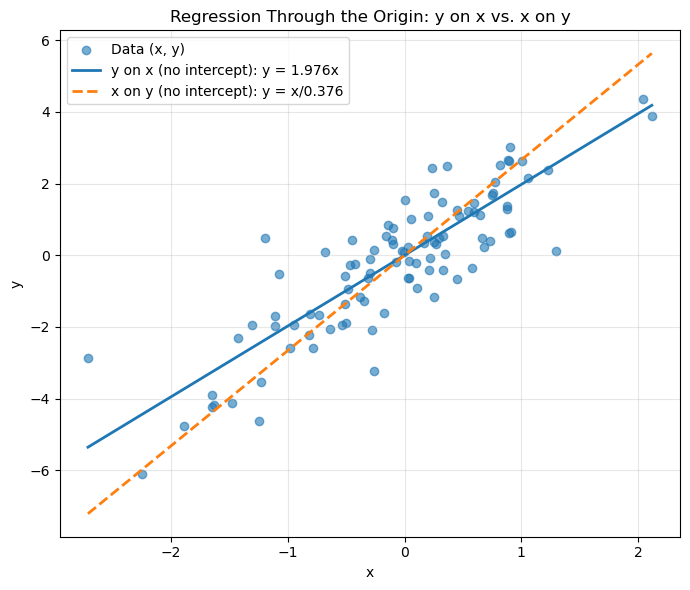

Saved: figs/q11_regression_through_origin.png


In [69]:
#(f) In R, show that when regression is performed with an intercept,the t-statistic for H0 : #1 = 0 is the same for the regression of yonto x as it is for the regression of x onto y.

%matplotlib inline

# Create folder if it does not exist
os.makedirs("figs", exist_ok=True)
fig, ax = plt.subplots(figsize=(7, 6))
# Scatter plot
ax.scatter(x, y, alpha=0.6, label="Data (x, y)")
# Regression line: y on x, through origin
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(
    xs,
    beta_hat * xs,
    lw=2,
    label=f"y on x (no intercept): y = {beta_hat:.3f}x"
)
# Regression line: x on y, through origin
ax.plot(
    xs,
    xs / beta_hat2,
    lw=2,
    linestyle="--",
    label=f"x on y (no intercept): y = x/{beta_hat2:.3f}"
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Regression Through the Origin: y on x vs. x on y")
ax.legend()
ax.grid(alpha=0.3)
# Adjust layout
plt.tight_layout()

# Save graph
plt.savefig(
    "figs/q11_regression_through_origin.png",
    dpi=130,
    bbox_inches="tight"
)
# Display graph
plt.show()
print("Saved: figs/q11_regression_through_origin.png")